In [1]:
import requests
import pandas as pd
import datetime
import json
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
import joblib
import sklearn

model = joblib.load('API_ML/app/data/ML_sup/model.pkl')
variable_importance = ({a:b for a,b in zip(model.feature_names_in_[model.coef_>0],model.coef_[model.coef_>0])})


In [7]:
df.values

array([[0.75506866, 0.1232885 , 0.13658934, 0.06798497, 0.26065119,
        0.05348428, 0.17245066, 0.06210906, 0.00369773, 0.0249102 ,
        0.0095124 , 0.02974811, 0.16115321, 0.36926941, 0.38999444,
        1.6648166 , 0.1831938 , 0.14021002, 0.0045296 , 0.12194381,
        0.0516082 , 0.10879093, 0.02104062, 0.38240338, 0.04249719,
        0.32944184, 0.09070169, 0.14756725, 0.00535148, 0.0938317 ,
        0.02441631, 0.00472735, 0.04127711]])

In [6]:


df = pd.DataFrame(variable_importance, index=[0])

# Generate plot
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(y=df.columns,width=df.values)
ax.set_title('feature importance')

# Save plot to a BytesIO buffer
img = io.BytesIO()
plt.savefig(img, format='png')
img.seek(0)
img_feat_import = base64.b64encode(img.getvalue()).decode('utf-8')


TypeError: only length-1 arrays can be converted to Python scalars

In [151]:
url = 'http://127.0.0.1:8000/KC8/'
headers = {
    'accept': 'application/json',
    'Content-Type': 'application/json'}

response = requests.get(url=url,headers=headers)
data = pd.DataFrame(response.json())

In [152]:
data.index = pd.to_datetime(data.Batch_KC8_date)
data = data[['Batch_KC8_masse']].sort_index()
data['masse_C_cum'] = (data['Batch_KC8_masse'] * (12*8 / ((12*8)+39))).cumsum()
data['masse_K_cum'] = (data['Batch_KC8_masse'] * (39 / ((12*8)+39))).cumsum()

<Axes: xlabel='Batch_KC8_date'>

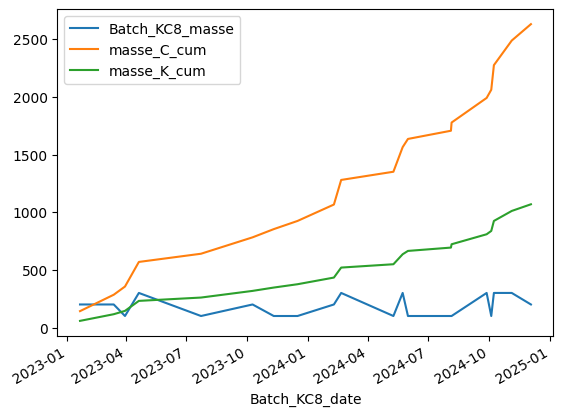

In [153]:
data.plot()

<Axes: >

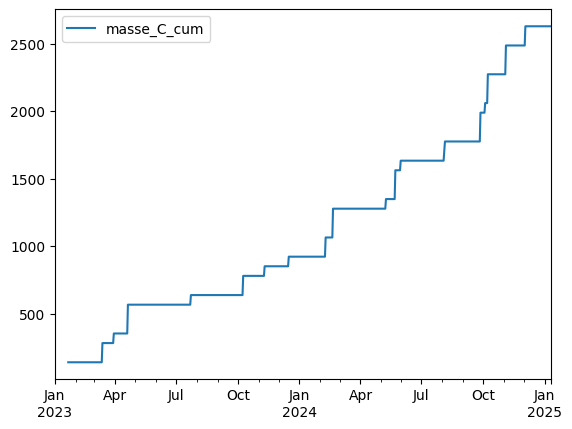

In [154]:
df = pd.DataFrame(index=pd.date_range(start='2023-01-01', end='2025-01-10'))
df2 = pd.merge(df,data[['masse_C_cum']] ,how='outer',left_index=True,right_index=True).ffill()
df2.plot()

In [155]:
url = 'http://127.0.0.1:8000/matieres_premieres/'
headers = {
    'accept': 'application/json',
    'Content-Type': 'application/json'}

response = requests.get(url=url,headers=headers)
data2 = pd.DataFrame(response.json())

In [156]:
data2.index = pd.to_datetime(data2.MP_date_reception)
data2 = data2.loc[data2.MP_nom=='Carbone',['MP_quantite']]
data2 = data2.sort_index().cumsum()

<Axes: >

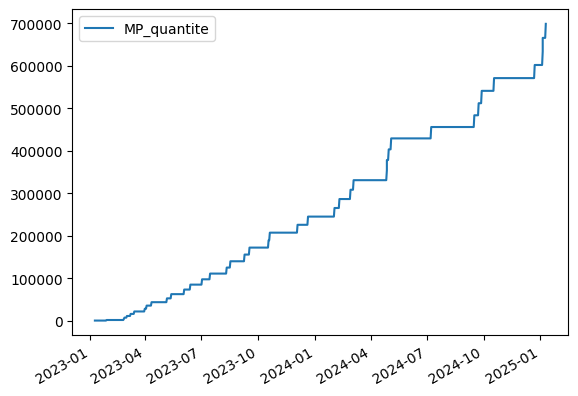

In [157]:
df = pd.DataFrame(index=pd.date_range(start='2023-01-01', end='2025-01-10'))
df3 = pd.merge(df,data2.cumsum(),how='outer',left_index=True,right_index=True).ffill()
df3.plot()

<Axes: >

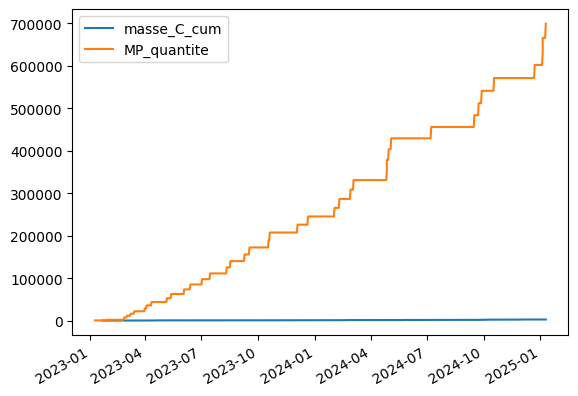

In [158]:
df4 = pd.merge(df2,df3 ,how='outer',left_index=True,right_index=True).ffill()
df4.plot()

<Axes: >

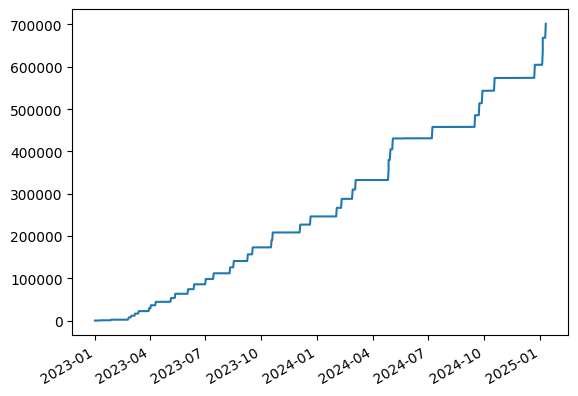

In [159]:
df4.fillna(0).sum(axis=1).plot()

In [160]:

(df3.iloc[:,0]-df3.iloc[:,1]).plot()

IndexError: single positional indexer is out-of-bounds

In [ ]:
data2

,MP_quantite
MP_date_reception,
2023-01-03,0.0
2023-04-18,0.0
2023-05-16,21.0
2023-07-11,21.0
2023-07-14,397.0
2023-07-16,397.0
2023-07-20,870.0
2023-09-21,1594.0
2023-10-23,1630.0


In [12]:
import pandas as pd

data = pd.DataFrame(index=pd.date_range('2022-01-01','2025-01-01'))


data

""
2022-01-01
2022-01-02
2022-01-03
2022-01-04
2022-01-05
...
2024-12-28
2024-12-29
2024-12-30
2024-12-31
